<a href="https://www.kaggle.com/code/navneet0094/ckplus-train-jafee-test?scriptVersionId=314031523" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-da/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.SA3.121.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.HA3.97.tiff
/kaggle/input/dataset

In [18]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [19]:
data = []
labels = []
subject_ids = []

dataset_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"
for label, emotion in enumerate(os.listdir(dataset_path)):
    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (981, 48, 48)
Labels: [0 1 2 3 4 5 6]


In [20]:
# import os, cv2, numpy as np

# ck_data = []
# ck_labels = []

# ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

# emotion_names = sorted(os.listdir(ck_path))  # keep consistent order

# for label, emotion in enumerate(emotion_names):
#     emotion_path = os.path.join(ck_path, emotion)

#     for img_name in os.listdir(emotion_path):
#         img_path = os.path.join(emotion_path, img_name)

#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#         if img is None:
#             continue
            
#         img = cv2.resize(img, (48,48))

#         ck_data.append(img)
#         ck_labels.append(label)

# ck_data = np.array(ck_data)
# ck_labels = np.array(ck_labels)

# print("CK+:", ck_data.shape)

In [21]:
# from PIL import Image

# jaffe_data = []
# jaffe_labels = []

# emotion_map = {
#     'AN':0, 'DI':1, 'FE':2,
#     'HA':3, 'SA':4, 'SU':5, 'NE':6
# }

# jaffe_path = "/kaggle/input/datasets/navneet0094/jafee-da/jaffe"

# for img_name in os.listdir(jaffe_path):
#     img_path = os.path.join(jaffe_path, img_name)

#     try:
#         img = Image.open(img_path).convert('L')
#         img = img.resize((48,48))
#         img = np.array(img)

#         emotion = img_name.split('.')[1][:2]
#         label = emotion_map[emotion]

#         jaffe_data.append(img)
#         jaffe_labels.append(label)

#     except:
#         continue

# jaffe_data = np.array(jaffe_data)
# jaffe_labels = np.array(jaffe_labels)

# print("JAFFE:", jaffe_data.shape)

In [22]:
# from skimage.feature import hog

# def extract_hog(images):
#     return np.array([
#         hog(img,
#             orientations=9,
#             pixels_per_cell=(8,8),
#             cells_per_block=(2,2))
#         for img in images
#     ])

# X_ck_hog = extract_hog(ck_data)
# X_jaffe_hog = extract_hog(jaffe_data)

# print("CK+ HOG:", X_ck_hog.shape)
# print("JAFFE HOG:", X_jaffe_hog.shape)

In [23]:
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# model = LinearSVC(max_iter=5000)

# # TRAIN
# model.fit(X_ck_hog, ck_labels)

# # TEST
# y_pred = model.predict(X_jaffe_hog)

# acc = accuracy_score(jaffe_labels, y_pred)

# print("CK+ → JAFFE Accuracy:", acc)

In [24]:
# emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']

# print(classification_report(jaffe_labels, y_pred, target_names=emotion_names))

In [25]:
# cm = confusion_matrix(jaffe_labels, y_pred)

# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=emotion_names,
#             yticklabels=emotion_names)

# plt.title("CK+ → JAFFE Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

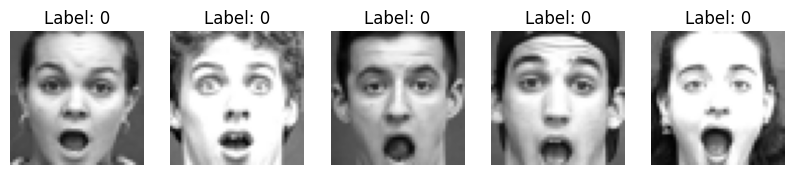

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

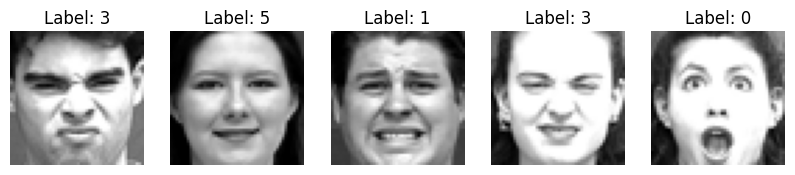

In [27]:
import random

plt.figure(figsize=(10,5))

for i in range(5):
    idx = random.randint(0, len(data)-1)
    plt.subplot(1,5,i+1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(f"Label: {labels[idx]}")
    plt.axis('off')

plt.show()

In [28]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (981, 900)


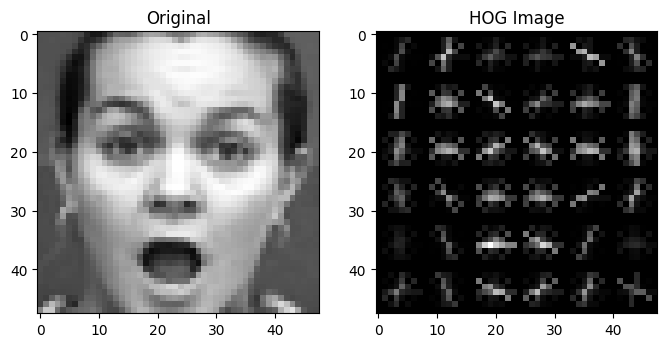

In [29]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import time

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, labels, test_size=0.3, random_state=42,shuffle=True
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  
X_test = scaler.transform(X_test)         

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)
hog_time = end - start

print("HOG Accuracy:", hog_acc)
print("HOG Time:", hog_time)

HOG Accuracy: 0.9796610169491525
HOG Time: 0.10345721244812012


In [32]:
emotion_names = os.listdir(dataset_path)
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       0.99      0.99      0.99        68
        fear       1.00      1.00      1.00        28
     sadness       0.93      1.00      0.97        28
     disgust       1.00      1.00      1.00        60
    contempt       0.89      0.85      0.87        20
       happy       1.00      1.00      1.00        52
       anger       0.97      0.95      0.96        39

    accuracy                           0.98       295
   macro avg       0.97      0.97      0.97       295
weighted avg       0.98      0.98      0.98       295



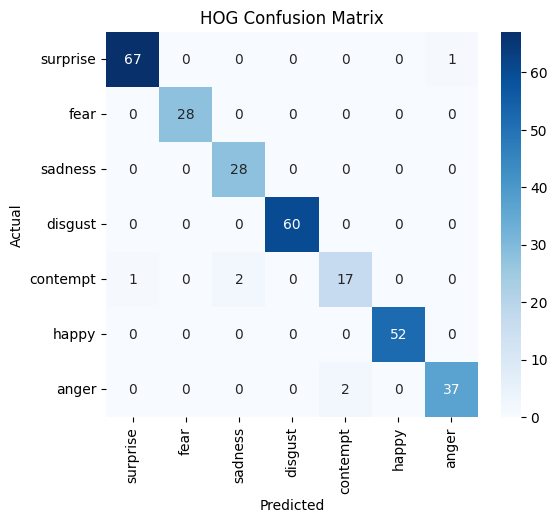

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

cv_scores = cross_val_score(pipeline, X_hog, labels, cv=10)

print("\n=== 10-Fold CV ===")
print("Fold Accuracies:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))


=== 10-Fold CV ===
Fold Accuracies: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Std Dev: 0.0


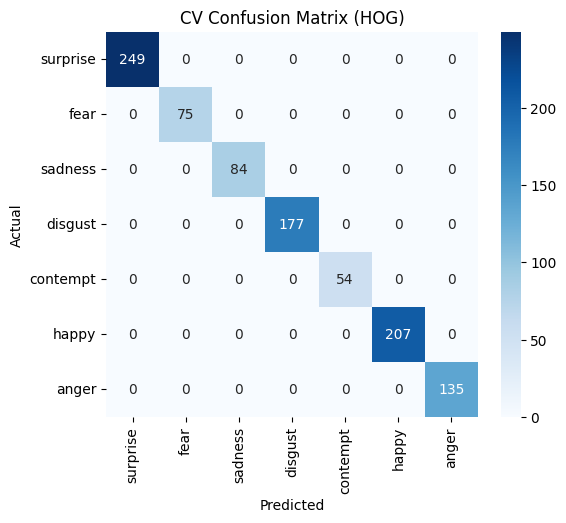

In [35]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# get predictions from CV
y_pred_cv = cross_val_predict(pipeline, X_hog, labels, cv=10)

# confusion matrix
cm = confusion_matrix(labels, y_pred_cv)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("CV Confusion Matrix (HOG)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [36]:

# classification report
print(classification_report(labels, y_pred_cv, target_names=emotion_names))

              precision    recall  f1-score   support

    surprise       1.00      1.00      1.00       249
        fear       1.00      1.00      1.00        75
     sadness       1.00      1.00      1.00        84
     disgust       1.00      1.00      1.00       177
    contempt       1.00      1.00      1.00        54
       happy       1.00      1.00      1.00       207
       anger       1.00      1.00      1.00       135

    accuracy                           1.00       981
   macro avg       1.00      1.00      1.00       981
weighted avg       1.00      1.00      1.00       981



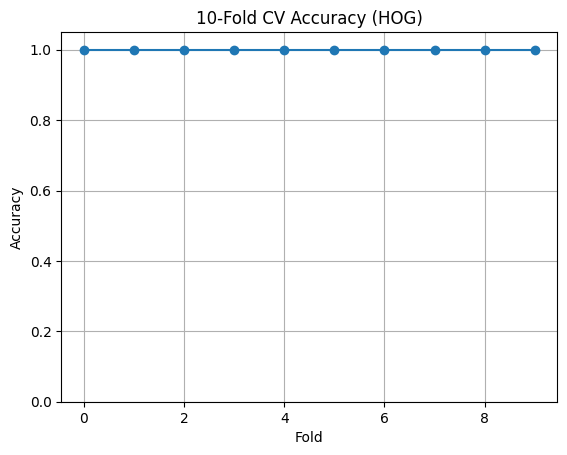

In [37]:
plt.plot(cv_scores, marker='o')
plt.title("10-Fold CV Accuracy (HOG)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid()
plt.show()